In [2]:
import pandas as pd

df = pd.read_csv("dataset/creditcard_2023.csv")  # check file
# V1-V28: Anonymized features representing various transaction attributes (e.g., time, location, etc.)
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


## Compare the mean vectors of the fraud and normal groups

Mean vector:

```
28-dimensional mean vector over all features [V1, V2, ..., V28]
```


Fraud:

$$\mu_{fraud} = [E(V_1), E(V_2), \ldots, E(V_{28})]$$

Normal:

$$\mu_{normal} = [E(V_1), E(V_2), \ldots, E(V_{28})]$$

---

### Why do we check this?

Each class is a set of points in 28-dimensional space.

If the "center" of those points differs between classes, that indicates a structural difference between fraud and normal transactions.

---

### How to calculate

With pandas it's straightforward:

```python
fraud_mean = df[df["Class"] == 1].iloc[:, 1:29].mean()
normal_mean = df[df["Class"] == 0].iloc[:, 1:29].mean()
```

(Adjust column indices to match your dataframe.)

The result: length-28 vectors for each group.


In [3]:
import numpy as np

# Standardized mean difference (두 집단 평균 차이를 공통 표준편차로 나눈 값.)
fraud = df[df["Class"] == 1].iloc[:, 1:29]
normal = df[df["Class"] == 0].iloc[:, 1:29]

fraud_mean = fraud.mean()
normal_mean = normal.mean()
# diff vector.
# 두 클래스가 공간에서 서로 다른 위치에 있는가?를 알아보기 위한 값. 즉, “선형 분리 가능성”을 보는 첫 번째 방법
mean_diff = fraud_mean - normal_mean

fraud_std = fraud.std()
normal_std = normal.std()

n_f = len(fraud)
n_n = len(normal)

# “두 집단이 같은 분산을 가진다”는 가정 하에서 그 공통 분산을 가장 효율적으로 추정한 값
# 합동(풀링) 분산(pooled variance)은 서로 다른 표본들이 같은 모집단 분산을 공유한다고 가정할 때, 
# 각 표본 분산을 자유도(표본 크기-1)로 가중 평균해 공통 분산을 더 정확히 추정하는 방법
pooled_std = np.sqrt(
    ((n_f - 1) * fraud_std**2 + (n_n - 1) * normal_std**2)
    / (n_f + n_n - 2)
)

# 단순히 diff vector가 아니라 smd를 보는 이유 : 두 집단의 분산이 다를 수 있으므로
# raw mean diff는 “위치 차이”만 봄, SMD는 “위치 차이를 노이즈 대비 얼마나 큰지” 본다
smd = (fraud_mean - normal_mean) / pooled_std



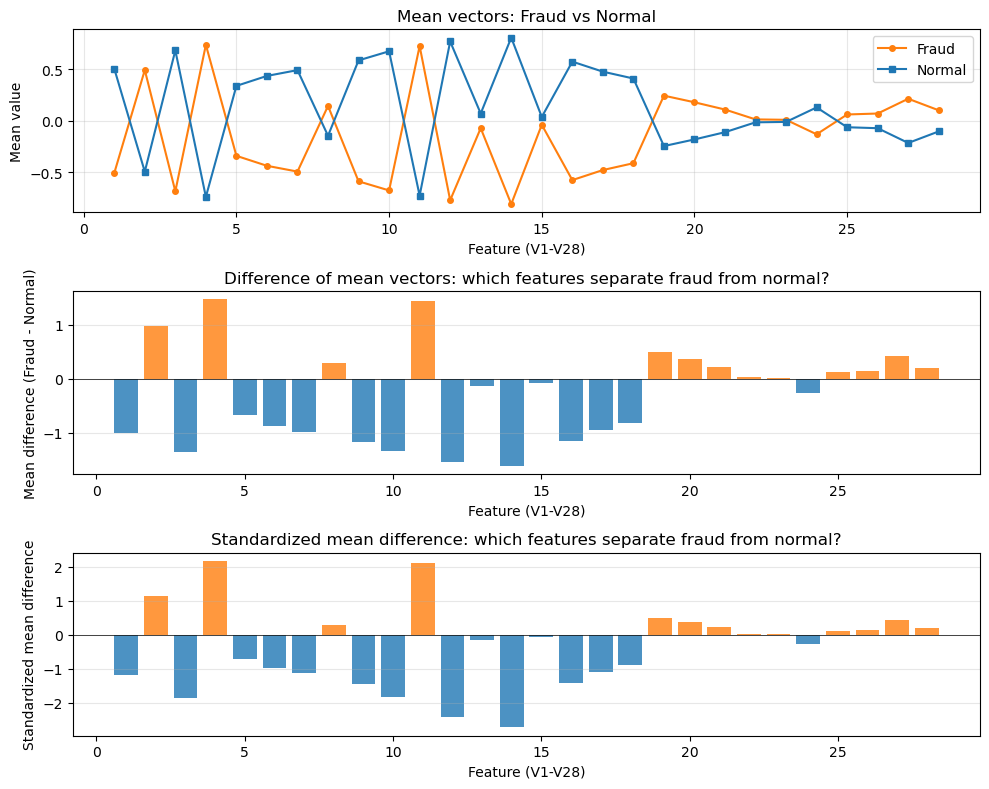

In [4]:
import matplotlib.pyplot as plt

# 1. Line plot: compare mean vectors across V1–V28 (most common way to visualize two mean vectors)
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

x = np.arange(1, 29)  # V1..V28
axes[0].plot(x, fraud_mean.values, "o-", label="Fraud", color="C1", markersize=4)
axes[0].plot(x, normal_mean.values, "s-", label="Normal", color="C0", markersize=4)
axes[0].set_xlabel("Feature (V1-V28)")
axes[0].set_ylabel("Mean value")
axes[0].set_title("Mean vectors: Fraud vs Normal")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Bar chart of difference: which dimensions separate the classes most
axes[1].bar(x, mean_diff.values, color=np.where(mean_diff.values >= 0, "C1", "C0"), alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_xlabel("Feature (V1-V28)")
axes[1].set_ylabel("Mean difference (Fraud - Normal)")
axes[1].set_title("Difference of mean vectors: which features separate fraud from normal?")
axes[1].grid(True, alpha=0.3, axis="y")

# 3. Standardized mean difference
axes[2].bar(x, smd.values, color=np.where(smd.values >= 0, "C1", "C0"), alpha=0.8)
axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].set_xlabel("Feature (V1-V28)")
axes[2].set_ylabel("Standardized mean difference")
axes[2].set_title("Standardized mean difference: which features separate fraud from normal?")
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [5]:
# distance (L2 norm) 두 클래스 중심 사이의 유클리디안 거리
# 다음엔 Mahalanobis Distance도 확인해보기. 왜냐면 단순 거리 = 분산 고려 안 함, Mahalanobis = 공분산 구조 반영 
# 좀 더 쉽게 설명하자면, 지금까지 본 건 "중심"에 차이가 있었나? 이고, 이 다음엔 얼마나 각 집단이 퍼져 있는지 봐야함.
# 중심이 다르더라도 분산이 크면 겹칠 수 있으니까 그럼 선형 분리가 어려울 수도 있고.
distance = np.linalg.norm(mean_diff)

print(distance)


4.711093465580457


### SMD interpretation:
- |SMD| > 2: very strong mean separation (≈ 2 pooled std apart)
    - V4(+), V11(+), V12(-), V14(-)
- |SMD| > 1: strong separation signal
- 4 features show very strong effect size
- 8 features show at least strong separation

Interpretation:
- Separation is concentrated in a subset of dimensions (12 features with strong or very strong effect), not sparse—so many directions contribute.
- Along those directions the effect is strong (4 very strong); fraud and normal have meaningful center shift in several dimensions.

### L2 norm of mean difference ≈ 4.7
Interpretation:
- In standardized PCA space, class centers are 4.7 units apart.
- This is not small relative to unit variance features.
- Suggests cumulative multi-dimensional separation.

Meaningful separation of the class centers suggests that linear separation may be possible. However, if each group is highly spread, the two groups can overlap, so to assess linear separability more clearly we need to look at the covariance structure. 

**Next step:** check covariance (e.g. within-class spread and Mahalanobis distance). 

In [6]:
cov_fraud = fraud.cov()
cov_normal = normal.cov()

# Summary stats: trace = total variance, det = generalized variance (spread in all directions)
print("Trace (total variance):  fraud =", np.trace(cov_fraud), "  normal =", np.trace(cov_normal))
# Determinant: generalized variance (volume of the covariance ellipsoid).
# Smaller = more correlation / more “narrow” in some directions.
print("Determinant (generalized variance):  fraud =", np.linalg.det(cov_fraud), "  normal =", np.linalg.det(cov_normal))
# Condition number: large value means one direction dominates (ill-conditioned) (가장 큰 고유값 / 가장 작은 고유값)
print("Condition number:  fraud =", np.linalg.cond(cov_fraud), "  normal =", np.linalg.cond(cov_normal))

Trace (total variance):  fraud = 30.41492514200657   normal = 14.488031971106698
Determinant (generalized variance):  fraud = 4.928608961572978e-15   normal = 5.892336544145e-12
Condition number:  fraud = 721.652743698366   normal = 29.596208561932574


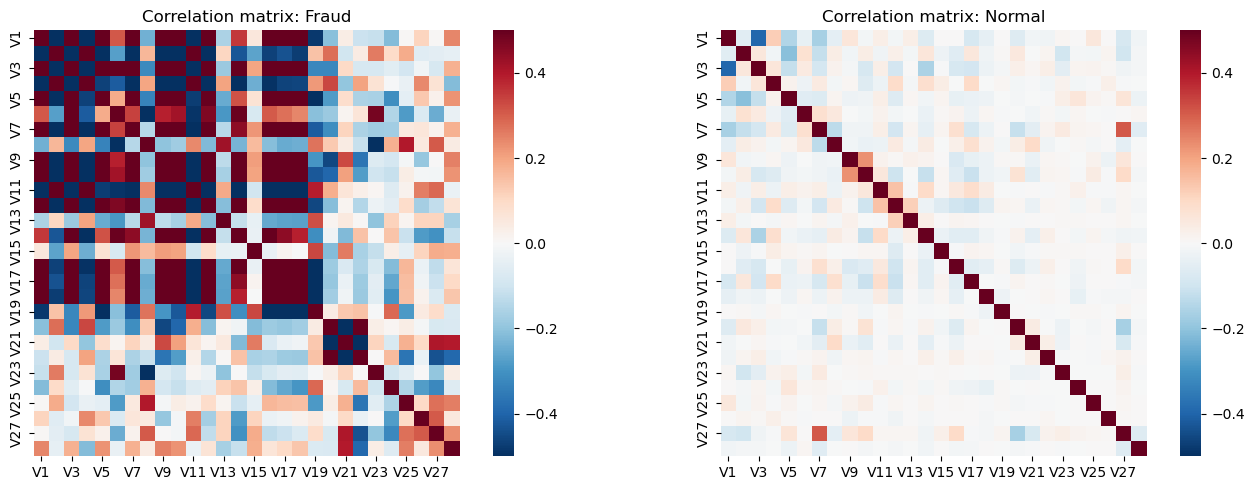

In [7]:
# Correlation matrices (scale -1 to 1): most interpretable for comparing structure between classes
import seaborn as sns
corr_fraud = fraud.corr()
corr_normal = normal.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vmin, vmax = -0.5, 0.5  # shared scale so plots are comparable

sns.heatmap(corr_fraud, cmap="RdBu_r", center=0, vmin=vmin, vmax=vmax, square=True, ax=axes[0])
axes[0].set_title("Correlation matrix: Fraud")
sns.heatmap(corr_normal, cmap="RdBu_r", center=0, vmin=vmin, vmax=vmax, square=True, ax=axes[1])
axes[1].set_title("Correlation matrix: Normal")
plt.tight_layout()
plt.show()

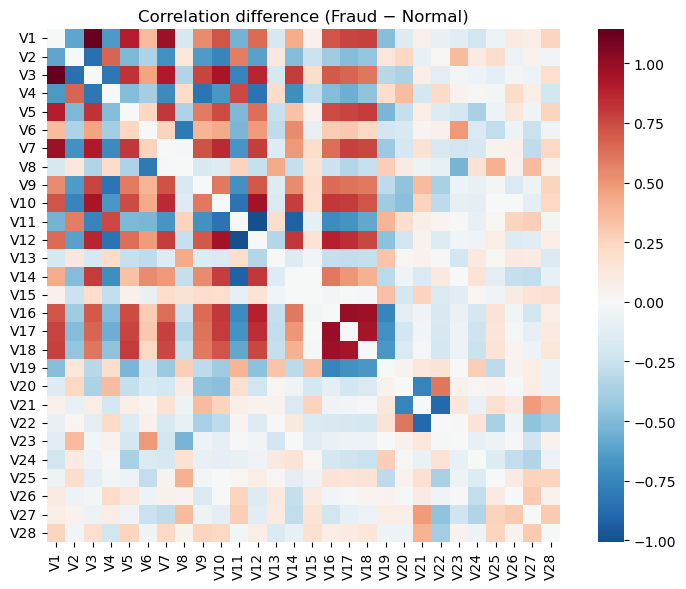

In [8]:
# Difference in correlation: Fraud - Normal (where structure differs most between classes)
corr_diff = corr_fraud - corr_normal
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_diff, cmap="RdBu_r", center=0, square=True, ax=ax)
ax.set_title("Correlation difference (Fraud − Normal)")
plt.tight_layout()
plt.show()



|           | Fraud | Normal |
| --------- | ----- | ------ |
| Total variance | Large | Small |
| Volume (det) | Very small | Larger |
| Condition | Very large | Small |

This can be interpreted as:

**Fraud:** spreads strongly in some directions and is very narrow in other directions  
→ needle-like structure in high-dimensional space

**Normal:** relatively balanced spread

### Squared Mahalanobis distance between class means (separability)

- **μ₀:** normal class mean vector (V1–V28)  
- **μ₁:** fraud class mean vector  
- **Σ:** pooled covariance (standard when assuming similar covariance):

  **Σ_pooled** = [(n₀−1)Σ₀ + (n₁−1)Σ₁] / (n₀ + n₁ − 2)

Then:

**D² = (μ₁ − μ₀)ᵀ Σ_pooled⁻¹ (μ₁ − μ₀)**

- **Meaning:** “How far apart are the class means relative to the common covariance?” (standardized distance).  
- **Larger D²** → class means are farther apart in this sense → **linear separability (e.g. LDA) is more plausible**.  
- This summarizes “is the data amenable to linear separation?” in one number. It does **not** guarantee perfect separation (we only look at means).

In [9]:
# Mahalanobis distance: separability of class means (D²)
# D² = (μ1 − μ0)ᵀ Σ_pooled⁻¹ (μ1 − μ0)
# Σ_pooled = ((n0−1)Σ0 + (n1−1)Σ1) / (n0 + n1 − 2)

# Mean vectors (already defined: fraud_mean, normal_mean from V1–V28)
mu0 = normal_mean.values   # normal class mean
mu1 = fraud_mean.values     # fraud class mean

# Sample sizes
n0 = len(normal)
n1 = len(fraud)

# Class covariance matrices (V1–V28)
Sigma0 = normal.cov().values
Sigma1 = fraud.cov().values

# Pooled covariance (LDA-style common covariance estimate).
# Note: if Σ0 != Σ1, this is still a useful summary but not an exact model assumption.
Sigma_pooled = ((n0 - 1) * Sigma0 + (n1 - 1) * Sigma1) / (n0 + n1 - 2)

# Squared Mahalanobis distance between the two means
diff = (mu1 - mu0).reshape(-1, 1)
# Use pinv for numerical stability (e.g. if fraud n is small and Σ is near-singular)
Sigma_inv = np.linalg.pinv(Sigma_pooled)
D2 = (diff.T @ Sigma_inv @ diff).item()

print(f"n0 (normal) = {n0}, n1 (fraud) = {n1}")
print(f"D² (squared Mahalanobis distance between class means) = {D2:.4f}")
print(f"D  (Mahalanobis distance) = {np.sqrt(D2):.4f}")
print()
print("Interpretation: Larger D² → class means are farther apart relative to spread (Σ).")


n0 (normal) = 284315, n1 (fraud) = 284315
D² (squared Mahalanobis distance between class means) = 12.9384
D  (Mahalanobis distance) = 3.5970

Interpretation: Larger D² → class means are farther apart relative to spread (Σ).


### Mahalanobis distance 결과값 D=3.597, D²=12.94 가 모델 선택에 주는 의미

이 값은 **평균(클래스 중심)이 공분산(퍼짐)을 감안해도 꽤 떨어져 있다**는 뜻

Logistic Regression / Linear SVM 같은 선형 분류기를 "베이스라인"으로 잡을 가치가 커짐
- 하지만 이게 곧 '선형이 최적'이라는 뜻은 아님
- fraud 쪽 공분산/상관 구조가 normal과 다르면 QDA나 비선형 모델이 더 좋아질 여지가 있음

즉,
"이 데이터는 '중심이 섞여서' 분류가 망하는 케이스는 아니다.
최소한 선형 베이스라인은 꽤 잘 나올 가능성이 높다."

- D가 0에 가까움: 중심이 거의 같음 → 선형/비선형 다 힘들 가능성
- D가 2~3 이상: 중심이 유의미하게 떨어짐 → 선형 모델도 충분히 승산 있음
- 이번 데이터는 D≈3.6: "중심 분리 신호가 강함" 쪽

### What D=3.597, D²=12.94 (Mahalanobis distance) means for model choice

This value means **the class means (centroids) are quite far apart even after accounting for covariance (spread)**.

That makes it worthwhile to use **linear classifiers as a baseline** (e.g. Logistic Regression, Linear SVM).
- That does not mean "linear is optimal"
- If fraud has a different covariance/correlation structure from normal, QDA or nonlinear models may still do better

In other words:
*"This dataset is not one where classification fails because the class centers overlap. At least a linear baseline has a good chance of working well."*

- **D close to 0:** centroids almost coincide → both linear and nonlinear models may struggle
- **D ≥ 2–3:** centroids are meaningfully separated → linear models have a real chance
- **Here D ≈ 3.6:** strong "center separation" signal
